Objective: Build a machine learning model to predict the
aggregate rating of a restaurant based on other features.

In [1]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
import sklearn

In [2]:
Dataset = pd.read_csv("Cognifyz_Restaurant_Dataset.csv", skipinitialspace=True)

In [3]:
Dataset.head(3)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270


In [4]:
Dataset.shape

(9551, 21)

In [5]:
print(pd.__version__)

2.3.2


In [6]:
Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [7]:
# Checking for null/missing values
Dataset.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [8]:
Dataset=Dataset.dropna()

In [9]:
Dataset["Restaurant Name"]

0               Le Petit Souffle
1               Izakaya Kikufuji
2         Heat - Edsa Shangri-La
3                           Ooma
4                    Sambo Kojin
                  ...           
9546                 Naml۱ Gurme
9547                Ceviz A��ac۱
9548                       Huqqa
9549                 A���k Kahve
9550    Walter's Coffee Roastery
Name: Restaurant Name, Length: 9542, dtype: object

In [10]:
Dataset['Longitude'][:50]

0     121.027535
1     121.014101
2     121.056831
3     121.056475
4     121.057508
5     121.056314
6     120.979667
7     120.979333
8     120.980090
9     121.056532
10    121.057916
11    121.060820
12    121.075419
13    121.033592
14    121.038110
15    121.057040
16    121.056587
17    120.951589
18    121.045878
19    121.046220
20    121.053725
21    121.053500
22    -47.881789
23    -47.882667
24    -47.882136
25    -47.888167
26    -47.915667
27    -47.915667
28    -47.907500
29    -47.910167
30    -47.890167
31    -47.923667
32    -48.019000
33    -48.019092
34    -48.016667
35    -47.889000
36    -47.872359
37    -47.956283
38    -47.872833
39    -47.868500
40    -47.885812
41    -47.921028
42    -43.377000
43    -43.178826
44    -43.186692
45    -43.175833
46    -43.176000
47    -43.191000
48    -43.227042
49    -43.211425
Name: Longitude, dtype: float64

In [11]:
Dataset['Votes'][:50]

0      314
1      591
2      270
3      365
4      229
5      336
6      520
7      677
8      621
9      532
10    1070
11     488
12     294
13     458
14     223
15      29
16      72
17     211
18     118
19     392
20     535
21     618
22       6
23       9
24      11
25      11
26      11
27      10
28       8
29       5
30       2
31      12
32       9
33       9
34      29
35      17
36       5
37      10
38       6
39      30
40       8
41       9
42       7
43      29
44      24
45      29
46      11
47      19
48      40
49      21
Name: Votes, dtype: int64

In [12]:
# # defining a function that shortens the categories that has lesser values
# def shorten_categories(categories, cutoff):
#     cat_mapping={}
#     for i in range(len(categories)):
#         if categories.values[i] >= cutoff:
#             cat_mapping[categories.index[i]]=categories.index[i]
#         else:
#             cat_mapping[categories.index[i]]= 'others'
#     return cat_mapping

In [13]:
# Restaurant_map=shorten_categories(Dataset['Restaurant Name'].value_counts(), 10)
# Dataset['Restaurant Name']=Dataset['Restaurant Name'].map(Restaurant_map)

# Dataset['Restaurant Name'].value_counts()

In [14]:
# Restaurant_map=shorten_categories(Dataset['Votes'].value_counts(), 100)
# Dataset['Votes']=Dataset['Votes'].map(Restaurant_map)

# Dataset['Votes'].value_counts()

In [15]:
Dataset['Rating text'].value_counts()

Rating text
Average      3734
Not rated    2148
Good         2096
Very Good    1078
Excellent     300
Poor          186
Name: count, dtype: int64

In [16]:
Dataset['Rating color'].value_counts()

Rating color
Orange        3734
White         2148
Yellow        2096
Green         1078
Dark Green     300
Red            186
Name: count, dtype: int64

In [17]:
Dataset['Price range'].value_counts()

Price range
1    4438
2    3113
3    1405
4     586
Name: count, dtype: int64

In [18]:
Dataset['Votes'].value_counts()

Votes
0       1094
1        483
2        327
3        244
4        207
        ... 
1126       1
1616       1
1040       1
5966       1
901        1
Name: count, Length: 1012, dtype: int64

In [19]:
Dataset['Cuisines'].value_counts()

Cuisines
North Indian                                             936
North Indian, Chinese                                    511
Chinese                                                  354
Fast Food                                                354
North Indian, Mughlai                                    334
                                                        ... 
Bengali, Fast Food                                         1
North Indian, Rajasthani, Asian                            1
Chinese, Thai, Malaysian, Indonesian                       1
Bakery, Desserts, North Indian, Bengali, South Indian      1
Italian, World Cuisine                                     1
Name: count, Length: 1825, dtype: int64

In [20]:
# Restaurant_map=shorten_categories(Dataset['Cuisines'].value_counts(),100)
# Dataset['Restaurant Name']=Dataset['Cuisines'].map(Restaurant_map)

# Dataset['Cuisines'][:20]

<Axes: xlabel='Price range', ylabel='Aggregate rating'>

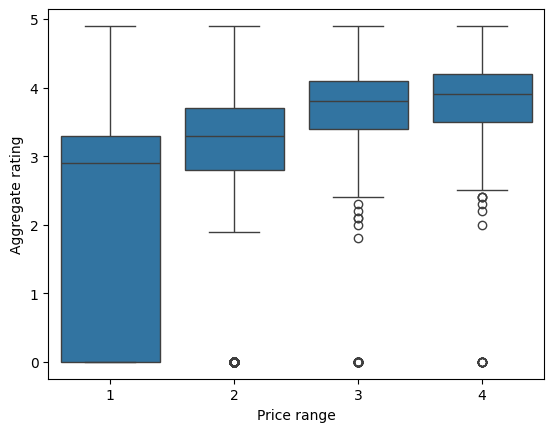

In [21]:
sns.boxplot(x=Dataset['Price range'], y=Dataset['Aggregate rating'])

<Axes: xlabel='Rating text', ylabel='Aggregate rating'>

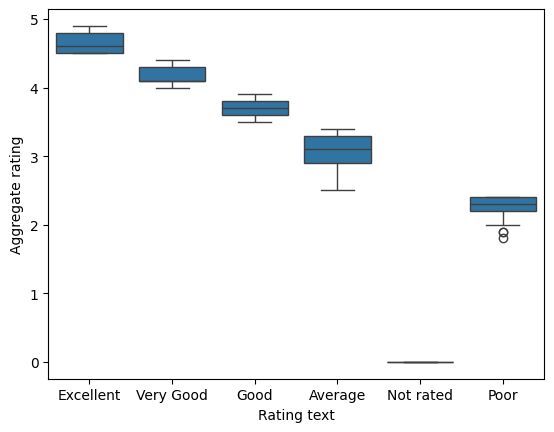

In [22]:
sns.boxplot(x=Dataset['Rating text'], y=Dataset['Aggregate rating'])

<Axes: xlabel='Rating color', ylabel='Aggregate rating'>

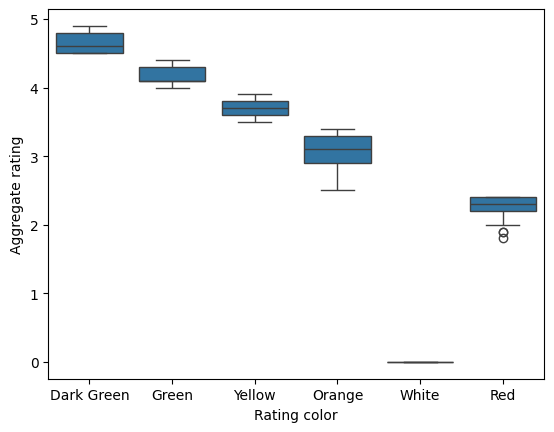

In [23]:
sns.boxplot(x=Dataset['Rating color'], y=Dataset['Aggregate rating'])

In [24]:
# Restaurant_map=shorten_categories(Dataset['Restaurant Name'].value_counts(), 10)
# Dataset['Restaurant Name']=Dataset['Restaurant Name'].map(Restaurant_map)

# Dataset['Restaurant Name'].value_counts()

In [25]:
# Restaurant_map=shorten_categories(Dataset['Votes'].value_counts(), 100)
# Dataset['Votes']=Dataset['Votes'].map(Restaurant_map)

# Dataset['Votes'].value_counts()

In [26]:
from sklearn.preprocessing import LabelEncoder

In [27]:
labelencoder=LabelEncoder()

In [28]:
obj=Dataset.select_dtypes(include=["object"])

In [29]:
for i in obj:
    Dataset[i]=labelencoder.fit_transform(Dataset[i])

In [30]:
Dataset.shape

(9542, 21)

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [32]:
x=Dataset.drop(['Aggregate rating'], axis=1)

In [33]:
Features=Dataset[["Restaurant Name", "Rating text", "Rating color","Longitude", "Votes","Cuisines"]]

In [34]:
x=Features

In [35]:
y=Dataset['Aggregate rating']

In [36]:
x.shape,y.shape

((9542, 6), (9542,))

In [37]:
x.values

array([[3.74200000e+03, 1.00000000e+00, 0.00000000e+00, 1.21027535e+02,
        3.14000000e+02, 9.20000000e+02],
       [3.16700000e+03, 1.00000000e+00, 0.00000000e+00, 1.21014101e+02,
        5.91000000e+02, 1.11100000e+03],
       [2.89200000e+03, 5.00000000e+00, 1.00000000e+00, 1.21056831e+02,
        2.70000000e+02, 1.67100000e+03],
       ...,
       [3.06300000e+03, 2.00000000e+00, 5.00000000e+00, 2.90346400e+01,
        6.61000000e+02, 1.11000000e+03],
       [5.12000000e+02, 5.00000000e+00, 1.00000000e+00, 2.90360190e+01,
        9.01000000e+02, 1.65700000e+03],
       [7.23100000e+03, 5.00000000e+00, 1.00000000e+00, 2.90260160e+01,
        5.91000000e+02, 3.31000000e+02]], shape=(9542, 6))

In [38]:
y.dtypes

dtype('float64')

In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
forest=RandomForestRegressor(n_estimators=100,random_state=45)

In [41]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((7633, 6), (7633,), (1909, 6), (1909,))

In [42]:
forest.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
y_pred=forest.predict(x_test)

In [44]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [45]:
# Evaluating the error in prediction
mse=mean_squared_error(y_test, y_pred)
r2_score=r2_score(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
print(f"mean squared error: \n {mse}\n")
print(f"coefficient(R2_score): \n {r2_score}\n")
print(f"mean absolute error: \n {mae}")

mean squared error: 
 0.030871880041906746

coefficient(R2_score): 
 0.9865190192406253

mean absolute error: 
 0.11964222105814563


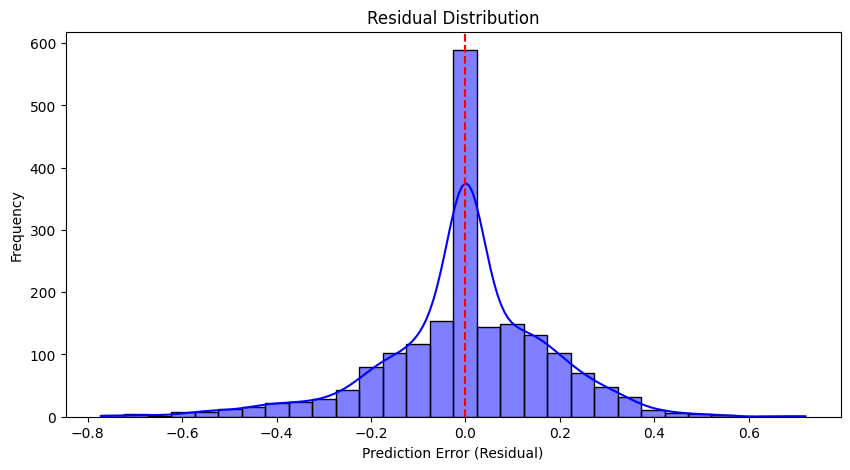

In [46]:
#visualizing the predicted and actual label to see prediction error
residuals = y_test - y_pred
# Plot residual distribution
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='dashed')  # Vertical line at zero residual
plt.title("Residual Distribution")
plt.xlabel("Prediction Error (Residual)")
plt.ylabel("Frequency")
plt.show()

Here the residuals are randomly distributed around 0.0, which means the models predictions will generalises well on unseen data.

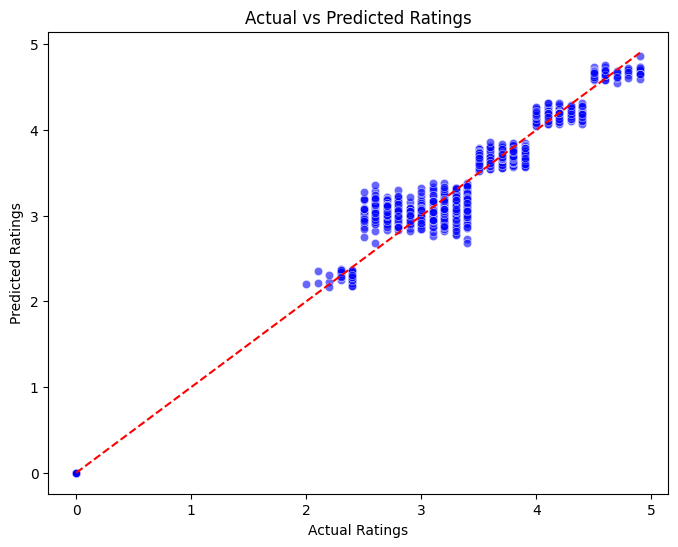

In [47]:
# Scatter plot of actual values vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color="blue", alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='dashed')  # Diagonal line
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()

The data point is closer to the red line diagonal which indicates the predictions are accurate

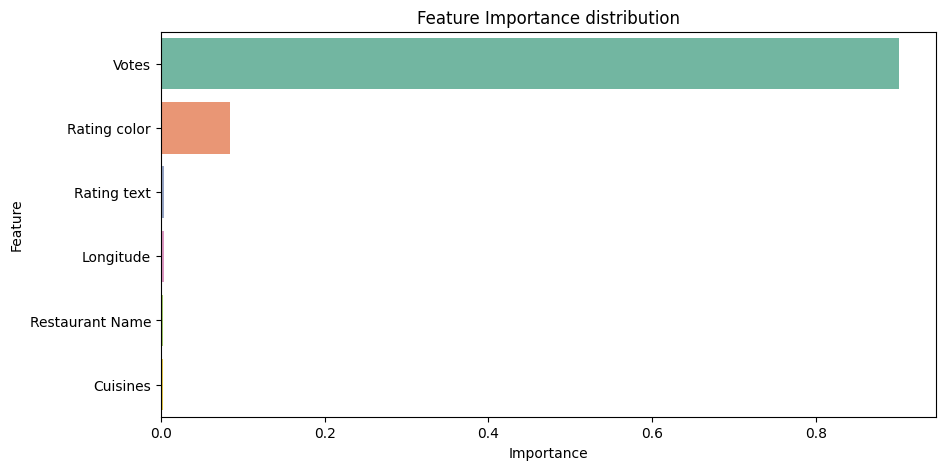

In [48]:
# Feature importance analysis
feature_importances = pd.DataFrame({
    "Feature": x.columns, 
    "Importance":forest.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Feature", data=feature_importances, palette="Set2")
plt.title("Feature Importance distribution")
plt.show()

Its gotten that VOTES column contributed around 95% of the prediction,RATING COLOR contributed around 15% while RATING TEXT
and the likes contributed lesser to the model predictions.Therefore Aggregate Ratings depends on vote and rating color. 

In [49]:
x['Rating text'].value_counts()

Rating text
0    3734
3    2148
2    2096
5    1078
1     300
4     186
Name: count, dtype: int64

In [50]:
x

,Restaurant Name,Rating text,Rating color,Longitude,Votes,Cuisines
0,3742,1,0,121.027535,314,920
1,3167,1,0,121.014101,591,1111
2,2892,5,1,121.056831,270,1671
3,4700,1,0,121.056475,365,1126
4,5515,1,0,121.057508,229,1122
...,...,...,...,...,...,...
9546,4436,5,1,28.977392,788,1813
9547,1310,5,1,29.041297,1034,1824
9548,3063,2,5,29.034640,661,1110
9549,512,5,1,29.036019,901,1657


In [51]:
              #Restaurant Name	Rating text	Rating color	Votes	Cuisines	Longitude
np.array([['Ooma' , 'Good' , 'Darkgreen' ,  29.036019, 387,'Japanese']])


array([['Ooma', 'Good', 'Darkgreen', '29.036019', '387', 'Japanese']],
      dtype='<U32')

In [52]:
import pickle

In [53]:
data={"model":forest,"restaurants":Dataset["Restaurant Name"], "rating":Dataset["Rating text"], "color":Dataset["Rating color"],"longitude":Dataset["Longitude"], "num of votes":Dataset["Votes"],"cuisines":Dataset["Cuisines"]}
with open("Restaurants_rating_model.sav", 'wb') as file:
    pickle.dump(data, file)

Saving the saved model in binary

In [54]:
# Loaded model
with open("Restaurants_rating_model.sav", 'rb') as file:
    data=pickle.load(file)

loaded_forest=data['model']
p_rest=data['restaurants']
p_rating=data["rating"]
p_color=data['color']
p_long=data['longitude']
p_votes=data["num of votes"]
p_cuisines=data['cuisines']

# converting the pandas series form 1D to 2D arry
p_rest = np.array(p_rest).reshape(-1, 1)
p_rating = np.array(p_rating).reshape(-1, 1)
p_color = np.array(p_color).reshape(-1, 1)
p_long = np.array(p_long).reshape(-1, 1)
p_votes = np.array(p_votes).reshape(-1, 1)
p_cuisines = np.array(p_cuisines).reshape(-1, 1)

In [55]:
# using the saved moodel to predict the input features
y_pred=loaded_forest.predict(x)
y_pred

array([4.641, 4.583, 4.34 , ..., 3.728, 4.179, 4.211], shape=(9542,))

In [56]:
# checking the dimension of the variables
p_rest.ndim,p_rating.ndim,p_color.ndim,p_long.ndim,p_votes.ndim,p_cuisines.ndim

(2, 2, 2, 2, 2, 2)

In [57]:
x.shape

(9542, 6)

In [58]:
p_rest.shape

(9542, 1)